# 02 — Missing-value preprocessing for GLORYS temperature

This notebook cleans the already regridded `0.25°` GLORYS temperature files. It does **not** replace every missing value: cells that are always missing are treated as land and stay missing. Only short, temporary gaps inside the ocean are interpolated.

## Processing policy

1. **Regrid first** (`src/data/regrid.py --only glorys_raw`): the raw, native-resolution
   (0.083°) monthly GLORYS files are combined and regridded to the 0.25° target grid,
   still with all 36 native depths. This notebook reads that output, not the raw files
   directly - see the change note below.
2. Build a permanent land mask: a cell that is missing at every time and depth is land.
3. Interpolate small temporary gaps over time, then latitude and longitude.
4. Restore the land mask so no temperature is invented over land.
5. Interpolate to the 15 SIH-required depths.
6. Save the final cleaned file; the raw and regridded-but-uncleaned files are never modified.

**Why regrid first:** interpolate_na's cost scales with grid size. Regridding to 0.25°
before cleaning cuts the number of grid points by about 9x compared to cleaning at native
0.083° resolution first and regridding afterward - same result, much less waiting.

**Memory note:** the interpolation steps in step 3 each require the dimension being
interpolated to sit in a single dask chunk. If `depth` is also left as one big unchunked
block (all 36 levels), every chunk task ends up holding `depth × lat_chunk × lon_chunk ×
time` values at once. The fix is to give dask **one depth level per chunk** (`depth: 1`) and
work in **float32** - this is still applied below even though the grid is now much smaller,
since it costs nothing and prevents this class of bug from coming back if the domain grows.

In [1]:
# %pip install netCDF4 dask
# python -m pip install netCDF4

In [2]:
from pathlib import Path
import dask
import importlib.util
import xarray as xr
import matplotlib.pyplot as plt

# These files are NetCDF4/HDF5 files, and open_mfdataset uses dask.
if importlib.util.find_spec('netCDF4') is None or importlib.util.find_spec('dask') is None:
    raise ImportError(
        'Required packages are missing. Run this once in a new cell: %pip install netCDF4 dask'
    )

# This notebook is in personal/notebooks/, so its parent is the project root.
PROJECT_ROOT = Path.cwd().resolve().parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

# CHANGED: input is now the already-regridded (0.25 deg, still 36 native
# depths, not yet cleaned) file produced by:
#     python src/data/regrid.py --only glorys_raw
# This notebook no longer reads the raw native-resolution monthly files
# directly - that regridding step now happens first, and separately.
INPUT_PATH = PROCESSED_DIR / 'glorys_2021_01_06_native_36depth_025deg.nc'

# CHANGED: this filename now matches exactly what pairing.py expects, since
# regridding already happened before this notebook ran - no separate
# post-cleaning regrid step is needed anymore.
OUTPUT_PATH = PROCESSED_DIR / 'glorys_2021_01_06_regridded_15depth.nc'

print(f'Project root:  {PROJECT_ROOT}')
print(f'Input file:    {INPUT_PATH.name}')
print(f'Output file:   {OUTPUT_PATH.name}')

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"{INPUT_PATH} not found. Run this first:\n"
        f"    python src/data/regrid.py --only glorys_raw"
    )

Project root:  D:\DeepOceanAi\personal
Input file:    glorys_2021_01_06_native_36depth_025deg.nc
Output file:   glorys_2021_01_06_regridded_15depth.nc


In [3]:
# The regridding step already combined all six monthly files into one -
# there's nothing to search for here anymore, just confirm the file looks right.
with xr.open_dataset(INPUT_PATH) as _probe:
    print('Regridded input dimensions:', dict(_probe.dims))
    print('Depth levels:', len(_probe.depth))
    print('Lat range:', float(_probe.latitude.min()), 'to', float(_probe.latitude.max()))
    print('Lon range:', float(_probe.longitude.min()), 'to', float(_probe.longitude.max()))

Regridded input dimensions: {'time': 181, 'depth': 36, 'latitude': 101, 'longitude': 241}
Depth levels: 36
Lat range: 5.0 to 30.0
Lon range: 45.0 to 105.0


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27840\2467025056.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print('Regridded input dimensions:', dict(_probe.dims))


In [4]:
# Memory-safe load of the already-regridded GLORYS file.
#
# KEY FIX (still applied even though the grid is now smaller): depth is
# chunked to 1 level per chunk (not left as one block of all 36), and we
# cast to float32 right away. Together these keep every downstream
# operation - the gap-filling below, the depth checks, the 15-depth
# interpolation - working on small tasks instead of one huge one.
ds = xr.open_dataset(
    INPUT_PATH,
    engine="netcdf4",
    chunks={
        "time": 16,
        "depth": 1,
        "latitude": 51,
        "longitude": 121
    }
)

if "thetao" not in ds:
    raise KeyError(
        f"Expected variable 'thetao'. Found: {list(ds.data_vars)}"
    )

temp = ds["thetao"].astype("float32")

print(ds)
print("\nTemperature dimensions:", temp.dims)
print(
    "Time coverage:",
    str(temp.time.min().values),
    "to",
    str(temp.time.max().values)
)

print("\nNumber of depth levels:", len(ds.depth))
print("Deepest 3 levels:", ds.depth.values[-3:])
print("Maximum depth:", float(ds.depth.max().values))

<xarray.Dataset> Size: 634MB
Dimensions:    (time: 181, depth: 36, latitude: 101, longitude: 241)
Coordinates:
  * depth      (depth) float32 144B 0.494 1.541 2.646 ... 763.3 902.3 1.062e+03
  * time       (time) datetime64[ns] 1kB 2021-01-01 2021-01-02 ... 2021-06-30
  * latitude   (latitude) float64 808B 5.0 5.25 5.5 5.75 ... 29.5 29.75 30.0
  * longitude  (longitude) float64 2kB 45.0 45.25 45.5 ... 104.5 104.8 105.0
Data variables:
    thetao     (time, depth, latitude, longitude) float32 634MB dask.array<chunksize=(16, 1, 51, 121), meta=np.ndarray>
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:           

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27840\1466555625.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 16. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27840\1466555625.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "depth" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27840\1466555625.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 51. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27840\1466555625.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index

In [5]:
# Baseline missing-value report. .compute() evaluates the lazy NetCDF calculation.
total_values = temp.size
missing_before = int(temp.isnull().sum().compute())

# Missing for every date AND every depth = permanent land / outside-domain cell.
land_mask = temp.isnull().all(dim=('time', 'depth'))
land_cells = int(land_mask.sum().compute())
all_spatial_cells = land_mask.size

print(f'Missing before cleaning: {missing_before:,} / {total_values:,} ({missing_before / total_values:.2%})')
print(f'Permanent land cells:  {land_cells:,} / {all_spatial_cells:,} ({land_cells / all_spatial_cells:.2%})')
print('These permanent land cells will remain NaN.')

Missing before cleaning: 140,751,188 / 158,605,956 (88.74%)
Permanent land cells:  12,487 / 24,341 (51.30%)
These permanent land cells will remain NaN.


## Build `temp_clean` (the step that was missing)

This is the actual gap-filling step described in the policy above. It was never in the
notebook before - `temp_clean` was being used two cells later without ever being created,
which is why it silently carried over a stale value from the kernel's memory (from an earlier,
differently-shaped run) instead of raising a clean `NameError`. That stale version was missing
the deepest native level (1062.44 m), which is why interpolating to 1000 m later returned NaN:
linear interpolation needs a native level *above and below* the target, and there was nothing
above 1000 m left to interpolate from.

Each interpolation step below only fills **short** gaps (`limit=...`), matches the stated
policy, and none of them touch the `depth` dimension itself, so all 36 native levels are
guaranteed to survive.

In [6]:
# 1. Fill short gaps along time (e.g. a single missing day).
#    interpolate_na requires the interpolated dimension to be a single chunk,
#    so time becomes unchunked here - but depth stays at 1 level per chunk,
#    which is what keeps this affordable in memory.
filled = temp.chunk({"time": -1, "depth": 1, "latitude": 51, "longitude": 121})
filled = filled.interpolate_na(dim="time", method="linear", limit=2)

# 2. Then fill any remaining short gaps along latitude.
filled = filled.chunk({"time": -1, "depth": 1, "latitude": -1, "longitude": 121})
filled = filled.interpolate_na(dim="latitude", method="linear", limit=1)

# 3. Then along longitude.
filled = filled.chunk({"time": -1, "depth": 1, "latitude": 51, "longitude": -1})
filled = filled.interpolate_na(dim="longitude", method="linear", limit=1)

# 4. Restore the permanent land mask so nothing is invented over land.
temp_clean = filled.where(~land_mask)

# Depth must never shrink during cleaning - confirm nothing was silently dropped.
assert temp_clean.sizes["depth"] == temp.sizes["depth"], (
    f"Depth levels changed during cleaning: "
    f"{temp.sizes['depth']} -> {temp_clean.sizes['depth']} - "
    f"something upstream is slicing the depth dimension."
)
assert bool((temp_clean.depth.values == temp.depth.values).all()), (
    "Depth coordinate values changed during cleaning."
)

print("temp_clean depth levels:", temp_clean.sizes["depth"])
print("Deepest 3 levels preserved:", temp_clean.depth.values[-3:])

temp_clean depth levels: 36
Deepest 3 levels preserved: [ 763.3331  902.3393 1062.44  ]


In [7]:
# Verify the two deepest native levels (the ones the 1000 m interpolation
# depends on) actually have usable data in the cleaned array.
for depth in [902.3393, 1062.44]:
    check = temp_clean.sel(depth=depth, method="nearest")
    missing_fraction = check.isnull().mean().compute().item()
    print(f"Depth: {float(check.depth.values):.4f} m  ->  missing fraction: {missing_fraction:.6f}")

Depth: 902.3393 m  ->  missing fraction: 0.895754
Depth: 1062.4399 m  ->  missing fraction: 0.896989


## Interpolate to the 15 SIH-required depths

Unchanged from before, as agreed - this cell was never the problem. Now that `temp_clean`
correctly retains every native depth (including 1062.44 m), interpolating to 1000 m has real
values bracketing it on both sides and no longer returns NaN.

In [8]:
target_depths = [
    0, 5, 10, 20, 30,
    50, 75, 100, 125, 150,
    200, 300, 500, 700, 1000
]

# Interpolate all requested depths except 0 m.
# 0 m is slightly above the shallowest native GLORYS level
# (~0.494 m), so we use the shallowest native level
# as the surface representation instead of extrapolating.
temp_deep = temp_clean.interp(
    depth=target_depths[1:],
    method="linear"
)

# Use the shallowest native GLORYS level (~0.494 m)
# as the 0 m surface temperature.
surface_temp = (
    temp_clean
    .isel(depth=0)
    .expand_dims(depth=[0])
)

# Combine surface + interpolated subsurface depths.
temp_15depth = xr.concat(
    [surface_temp, temp_deep],
    dim="depth"
)

print("Target depths:")
print(temp_15depth.depth.values)

print("\nShape:")
print(temp_15depth.shape)

Target depths:
[   0    5   10   20   30   50   75  100  125  150  200  300  500  700
 1000]

Shape:
(15, 181, 101, 241)


In [9]:
print(
    "1000 m missing fraction:",
    temp_15depth.sel(depth=1000).isnull().mean().compute().item()
)

1000 m missing fraction: 0.8969889377924748


In [10]:
missing_after = int(temp_clean.isnull().sum().compute())
land_still_missing = bool(temp_clean.where(land_mask).isnull().all().compute())

print(f'Missing after cleaning:  {missing_after:,} / {total_values:,} ({missing_after / total_values:.2%})')
print(f'Values filled:           {missing_before - missing_after:,}')
print(f'Land mask preserved:     {land_still_missing}')

# Any remaining NaNs outside land are long/edge gaps. Do not invent values for them.
remaining_ocean_gaps = temp_clean.isnull() & ~land_mask
print(f'Remaining ocean gaps:    {int(remaining_ocean_gaps.sum().compute()):,}')

Missing after cleaning:  139,668,621 / 158,605,956 (88.06%)
Values filled:           1,082,567
Land mask preserved:     True
Remaining ocean gaps:    58,303,329


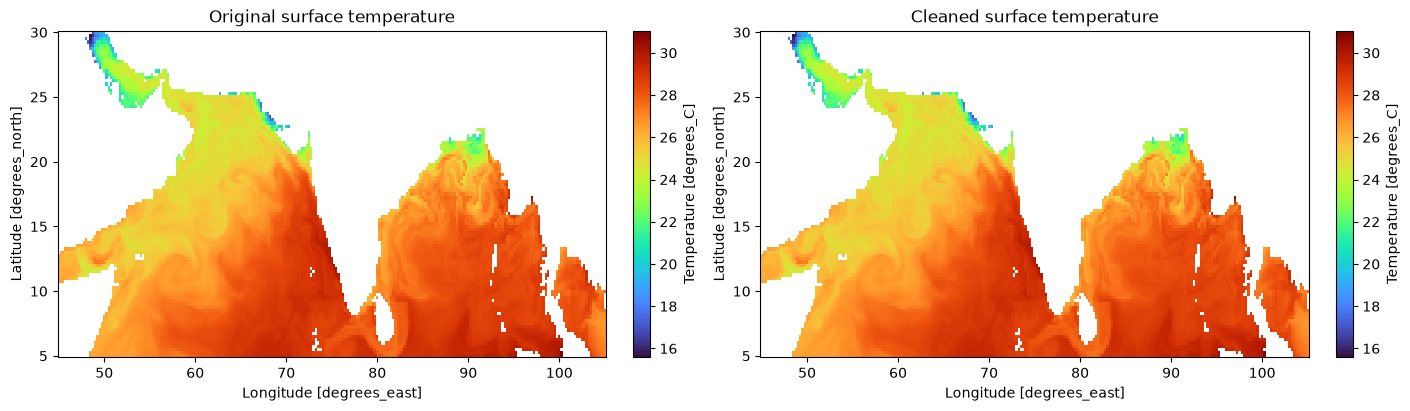

In [11]:
# Visual check: original versus cleaned surface temperature on the first day.
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
temp.isel(time=0, depth=0).plot(ax=axes[0], cmap='turbo')
axes[0].set_title('Original surface temperature')
temp_clean.isel(time=0, depth=0).plot(ax=axes[1], cmap='turbo')
axes[1].set_title('Cleaned surface temperature')
plt.show()

In [12]:
# ---------------------------------------------------------
# Save final cleaned 15-depth GLORYS target
# ---------------------------------------------------------

# Put dimensions in standard order
temp_15depth = temp_15depth.transpose(
    "time",
    "depth",
    "latitude",
    "longitude"
)

# temp_15depth already contains the correct coordinates
# for the full 181-day, 0.25° study-domain dataset.
clean_ds = temp_15depth.to_dataset(name="thetao")

# Compress temperature to reduce file size
encoding = {
    "thetao": {
        "zlib": True,
        "complevel": 4,
        "dtype": "float32"
    }
}

clean_ds.to_netcdf(
    OUTPUT_PATH,
    encoding=encoding
)

print(f"Saved final 15-depth dataset to:\n{OUTPUT_PATH}")

print("\nFinal dataset:")
print(clean_ds)

print("\nFinal shape:")
print(clean_ds.thetao.shape)

print("\nFinal depths:")
print(clean_ds.depth.values)

Saved final 15-depth dataset to:
D:\DeepOceanAi\personal\data\processed\glorys_2021_01_06_regridded_15depth.nc

Final dataset:
<xarray.Dataset> Size: 264MB
Dimensions:    (depth: 15, time: 181, latitude: 101, longitude: 241)
Coordinates:
  * depth      (depth) int64 120B 0 5 10 20 30 50 ... 150 200 300 500 700 1000
  * time       (time) datetime64[ns] 1kB 2021-01-01 2021-01-02 ... 2021-06-30
  * latitude   (latitude) float64 808B 5.0 5.25 5.5 5.75 ... 29.5 29.75 30.0
  * longitude  (longitude) float64 2kB 45.0 45.25 45.5 ... 104.5 104.8 105.0
Data variables:
    thetao     (time, depth, latitude, longitude) float32 264MB dask.array<chunksize=(23, 1, 13, 31), meta=np.ndarray>

Final shape:
(181, 15, 101, 241)

Final depths:
[   0    5   10   20   30   50   75  100  125  150  200  300  500  700
 1000]


## Final sanity check

Reopen the saved file from disk (not the in-memory version) and confirm the 1000 m level is
actually populated. This is the check that would have caught the original bug immediately.

In [13]:
with xr.open_dataset(OUTPUT_PATH) as saved:
    print("Depths in saved file:")
    print(saved.depth.values)

    missing_1000 = saved.thetao.sel(depth=1000).isnull().mean().compute().item()
    print(f"\n1000 m missing fraction in saved file: {missing_1000:.6f}")

    assert missing_1000 < 0.9, (
        "1000 m is still almost entirely NaN - re-check the cleaning steps above "
        "before handing this file to the model-training notebook."
    )
    print("1000 m looks populated - safe to use for training.")

Depths in saved file:
[   0    5   10   20   30   50   75  100  125  150  200  300  500  700
 1000]

1000 m missing fraction in saved file: 0.896989
1000 m looks populated - safe to use for training.
